#### Missing Value Detection

Missing count per column:
Name          0
Age           3
Score         2
City          2
Attendance    2
dtype: int64

Missing % per column:
Age           37.5
Score         25.0
City          25.0
Attendance    25.0
dtype: float64


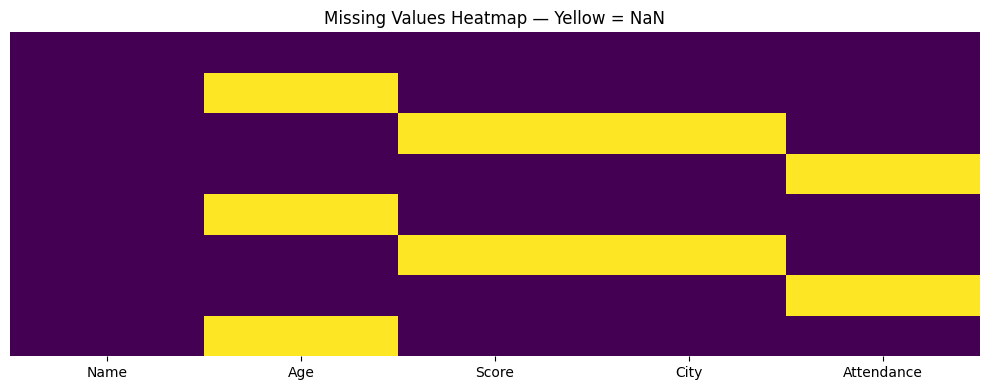

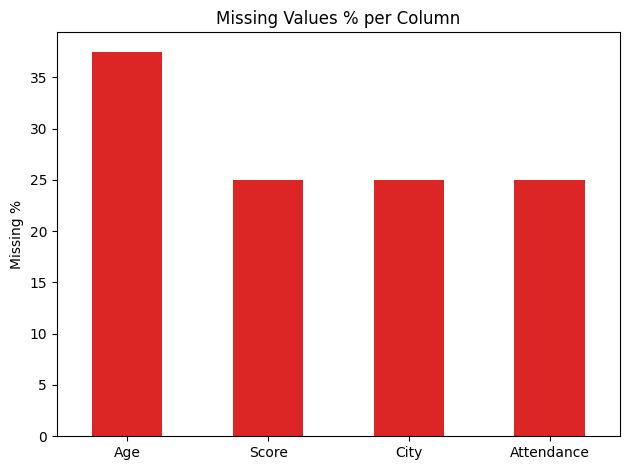


Any NaN present? True
Total NaN cells: 9


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Inline dataset: Student exam records ───
data = {
    'Name':       ['Aarav', 'Priya', 'Ravi', 'Sneha', 'Karan', 'Divya', 'Mohit', 'Ananya'],
    'Age':        [22,      np.nan,  25,      23,      np.nan,  21,      24,      np.nan ],
    'Score':      [85,      90,      np.nan,  78,      88,      np.nan,  72,      95     ],
    'City':       ['Mumbai','Delhi', np.nan,  'Surat', 'Mumbai',np.nan, 'Delhi', 'Pune' ],
    'Attendance': [90,      85,      80,      np.nan,  92,      88,      np.nan,  95     ],
}
df = pd.DataFrame(data)

# ─── 1. Basic detection ───
print("Missing count per column:")
print(df.isnull().sum())
# Age: 3, Score: 2, City: 2, Attendance: 2

print("\nMissing % per column:")
missing_pct = df.isnull().sum() / len(df) * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False))
# Age: 37.5%, Score: 25.0%, City: 25.0%, Attendance: 25.0%

# ─── 2. Heatmap of missing values ───
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False,
            cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap — Yellow = NaN')
plt.tight_layout()
plt.show()

# ─── 3. Bar chart of missing % ───
missing_pct[missing_pct > 0].plot(kind='bar', color='#dc2626')
plt.title('Missing Values % per Column')
plt.ylabel('Missing %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ─── 4. Quick check: any missing? ───
print("\nAny NaN present?", df.isnull().values.any())   # True
print("Total NaN cells:", df.isnull().sum().sum())

#### SimpleImputer — Mean & Median

In [9]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# ─── Sample data with NaNs ───
df = pd.DataFrame({
    'age':    [25, np.nan, 30, np.nan, 45, 28, np.nan],
    'salary': [50000, 60000, np.nan, 75000, np.nan, 55000, 80000],
    'score':  [np.nan, 85, 90, np.nan, 78, 92, 88]
})

print("Before Imputation:")
display(df)
print("\nMissing values:\n", df.isnull().sum())

# ─── Mean Imputer ───
mean_imputer = SimpleImputer(strategy='mean')

# fit_transform on numerical columns
df_mean = pd.DataFrame(
    mean_imputer.fit_transform(df),
    columns=df.columns
)
print("\nAfter MEAN Imputation:")
display(df_mean)

# ─── Median Imputer ───
median_imputer = SimpleImputer(strategy='median')
df_median = pd.DataFrame(
    median_imputer.fit_transform(df),
    columns=df.columns
)
print("\nAfter MEDIAN Imputation:")
display(df_median)

# ─── Check what value was learned ───
print("\nMean values learned:", mean_imputer.statistics_)
# [mean_age, mean_salary, mean_score]

Before Imputation:


,age,salary,score
0,25.0,50000.0,NaN
1,NaN,60000.0,85.0
2,30.0,NaN,90.0
3,NaN,75000.0,NaN
4,45.0,NaN,78.0
5,28.0,55000.0,92.0
6,NaN,80000.0,88.0



Missing values:
 age       3
salary    2
score     2
dtype: int64

After MEAN Imputation:


,age,salary,score
0,25.0,50000.0,86.6
1,32.0,60000.0,85.0
2,30.0,64000.0,90.0
3,32.0,75000.0,86.6
4,45.0,64000.0,78.0
5,28.0,55000.0,92.0
6,32.0,80000.0,88.0



After MEDIAN Imputation:


,age,salary,score
0,25.0,50000.0,88.0
1,29.0,60000.0,85.0
2,30.0,60000.0,90.0
3,29.0,75000.0,88.0
4,45.0,60000.0,78.0
5,28.0,55000.0,92.0
6,29.0,80000.0,88.0



Mean values learned: [3.20e+01 6.40e+04 8.66e+01]


#### Categorical SimpleImputer — most_frequent & constant

In [3]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# ─── Sample data ───
df = pd.DataFrame({
    'city':     ['Mumbai', 'Delhi', np.nan, 'Mumbai', np.nan, 'Surat'],
    'gender':   ['Male', np.nan, 'Female', 'Male', 'Female', np.nan],
    'category': [np.nan, 'Electronics', 'Clothing', np.nan, 'Electronics', 'Food']
})

print("Before Imputation:")
print(df)

# ─── Strategy 1: most_frequent ───
freq_imputer = SimpleImputer(strategy='most_frequent')
df_freq = pd.DataFrame(
    freq_imputer.fit_transform(df),
    columns=df.columns
)
print("\nAfter MOST FREQUENT Imputation:")
print(df_freq)

print("\nMost frequent values learned:", freq_imputer.statistics_)
# ['Mumbai', 'Male', 'Electronics']

# ─── Strategy 2: constant ───
const_imputer = SimpleImputer(strategy='constant',
                               fill_value='Unknown')
df_const = pd.DataFrame(
    const_imputer.fit_transform(df),
    columns=df.columns
)
print("\nAfter CONSTANT Imputation ('Unknown'):")
print(df_const)

Before Imputation:
     city  gender     category
0  Mumbai    Male          NaN
1   Delhi     NaN  Electronics
2     NaN  Female     Clothing
3  Mumbai    Male          NaN
4     NaN  Female  Electronics
5   Surat     NaN         Food

After MOST FREQUENT Imputation:
     city  gender     category
0  Mumbai    Male  Electronics
1   Delhi  Female  Electronics
2  Mumbai  Female     Clothing
3  Mumbai    Male  Electronics
4  Mumbai  Female  Electronics
5   Surat  Female         Food

Most frequent values learned: ['Mumbai' 'Female' 'Electronics']

After CONSTANT Imputation ('Unknown'):
      city   gender     category
0   Mumbai     Male      Unknown
1    Delhi  Unknown  Electronics
2  Unknown   Female     Clothing
3   Mumbai     Male      Unknown
4  Unknown   Female  Electronics
5    Surat  Unknown         Food


#### Categorical — Constant Fill & Custom Strategies

In [4]:
import pandas as pd
import numpy as np

# ─── Inline dataset: E-commerce orders (Flipkart style) ───
data = {
    'order_id':     [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'city':         ['Mumbai', 'Delhi', np.nan, 'Mumbai', np.nan,
                     'Surat',  'Delhi', 'Mumbai', np.nan, 'Pune'],
    'gender':       ['Male', np.nan, 'Female', 'Male', 'Female',
                     np.nan, 'Male', np.nan,   'Female', 'Male'],
    'product_type': ['Electronics', 'Clothing', 'Electronics', np.nan,
                     'Clothing', 'Food', np.nan, 'Electronics',
                     'Clothing', 'Food'],
    'occupation':   [np.nan, 'Engineer', np.nan, 'Doctor', 'Teacher',
                     np.nan, 'Engineer', 'Teacher', np.nan, 'Doctor'],
    'rating':       [4.5, 3.8, np.nan, 4.0, 4.2, np.nan,
                     3.5, 4.8, 4.1, np.nan],
    'payment_mode': ['UPI', 'Card', 'UPI', np.nan, 'UPI',
                     'COD', 'UPI', np.nan, 'Card', 'UPI'],
}
df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
print("Missing values before:\n", df.isnull().sum())

# ─── pandas fillna() — most common beginner approach ───

# Method 1: Specific value se fill karo (constant)
df['city'] = df['city'].fillna('Unknown')
df['gender'] = df['gender'].fillna('Not Specified')
df['occupation'] = df['occupation'].fillna('Not Disclosed')

# Method 2: Mode (most frequent) se fill karo
df['payment_mode'] = df['payment_mode'].fillna(df['payment_mode'].mode()[0])

# Method 3: Multiple columns ek saath — dict se
df.fillna({
    'product_type': 'General',
    'rating':       df['rating'].median()   # Numerical bhi mix kar sakte ho!
}, inplace=True)

print("\nMissing values after:\n", df.isnull().sum())
# All zeros!
print("\nCleaned dataset:")
print(df)

Dataset shape: (10, 7)
Missing values before:
 order_id        0
city            3
gender          3
product_type    2
occupation      4
rating          3
payment_mode    2
dtype: int64

Missing values after:
 order_id        0
city            0
gender          0
product_type    0
occupation      0
rating          0
payment_mode    0
dtype: int64

Cleaned dataset:
   order_id     city         gender product_type     occupation  rating  \
0       101   Mumbai           Male  Electronics  Not Disclosed     4.5   
1       102    Delhi  Not Specified     Clothing       Engineer     3.8   
2       103  Unknown         Female  Electronics  Not Disclosed     4.1   
3       104   Mumbai           Male      General         Doctor     4.0   
4       105  Unknown         Female     Clothing        Teacher     4.2   
5       106    Surat  Not Specified         Food  Not Disclosed     4.1   
6       107    Delhi           Male      General       Engineer     3.5   
7       108   Mumbai  Not Specifi

#### Most Frequent Imputation — Titanic Data

In [5]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# ─── Inline dataset: Passenger booking records ───
data = {
    'Pclass':   [1, 3, 2, 3, 1, 3, 2, 3, 1, 3, 2, 3, 3, 1, 2,
                 3, 3, 1, 2, 3],
    'Sex':      ['male','female','male','male','female','male',
                 'female','male','male','female','male','male',
                 'female','female','male','male','female','male',
                 'female','male'],
    'Embarked': ['S', 'C', 'S', 'S', np.nan, 'S', 'Q', 'S', 'C',
                 'S', 'S', np.nan, 'S', 'C', 'S', 'S', 'Q', 'C',
                 'S', 'S'],
    'Survived': [1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
                 0, 0, 1, 1, 0, 0, 1, 1, 1, 0],
}
df = pd.DataFrame(data)

# ─── Step 1: Missing values check ───
print("Missing values before:")
print(df[['Pclass', 'Sex', 'Embarked']].isnull().sum())
# Embarked: 2 missing

# ─── Step 2: Most Frequent Imputation ───
cols = ['Pclass', 'Sex', 'Embarked']

mf_imputer = SimpleImputer(strategy='most_frequent')
df_imp = pd.DataFrame(
    mf_imputer.fit_transform(df[cols]),
    columns=cols
)

# ─── Step 3: What did the imputer learn? ───
print("\nLearned most frequent values:", mf_imputer.statistics_)
# [3, 'male', 'S']  ← Pclass=3, Sex=male, Embarked=S

# ─── Step 4: Verify — no NaN remaining ───
print("\nMissing after imputation:")
print(df_imp.isnull().sum())   # All zeros!

# ─── Step 5: Before vs After — Embarked column ───
print("\nEmbarked before:")
print(df['Embarked'].value_counts(dropna=False))
#  S     16,  C    3,  Q    2,  NaN  2

print("\nEmbarked after:")
print(df_imp['Embarked'].value_counts())
#  S     18,  C    3,  Q    2   ← 2 NaN replaced with 'S' (most frequent)

Missing values before:
Pclass      0
Sex         0
Embarked    2
dtype: int64

Learned most frequent values: [3 'male' 'S']

Missing after imputation:
Pclass      0
Sex         0
Embarked    0
dtype: int64

Embarked before:
Embarked
S      12
C       4
NaN     2
Q       2
Name: count, dtype: int64

Embarked after:
Embarked
S    14
C     4
Q     2
Name: count, dtype: int64


#### Common Pitfall — Distribution Distortion Visualization

Missing: 38.5%

Original (non-null) distribution:
city
Mumbai       0.318699
Delhi        0.281301
Chennai      0.203252
Bangalore    0.196748
Name: proportion, dtype: float64

After most_frequent imputation:
city_imputed
Mumbai       0.581
Delhi        0.173
Chennai      0.125
Bangalore    0.121
Name: proportion, dtype: float64


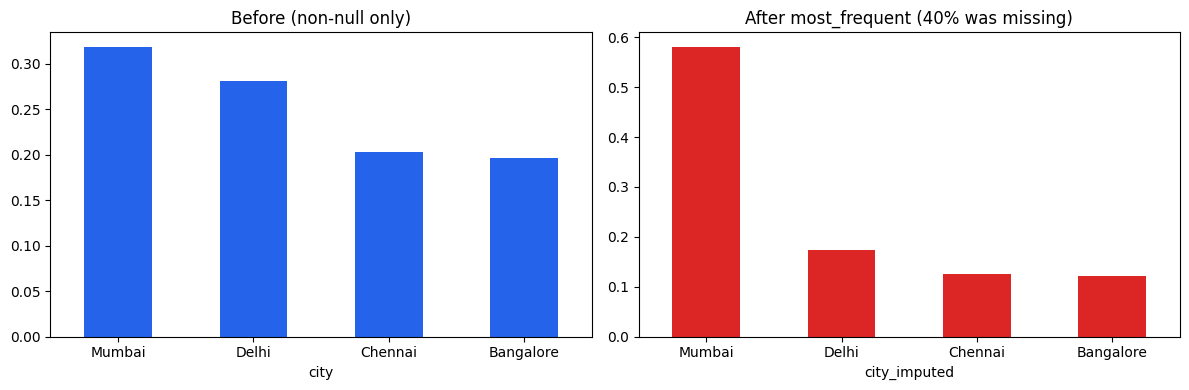

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# ─── Simulated data: 40% missing ───
np.random.seed(42)
n = 1000
cities = np.random.choice(['Mumbai', 'Delhi', 'Bangalore', 'Chennai'],
                           size=n, p=[0.3, 0.3, 0.2, 0.2])

# 40% random missing inject karo
mask = np.random.random(n) < 0.40
cities_missing = cities.astype(object)
cities_missing[mask] = np.nan

df = pd.DataFrame({'city': cities_missing})
print(f"Missing: {df['city'].isnull().mean()*100:.1f}%")

# ─── Before imputation distribution ───
before = df['city'].value_counts(normalize=True, dropna=True)
print("\nOriginal (non-null) distribution:")
print(before)

# ─── Apply most_frequent imputation ───
imp = SimpleImputer(strategy='most_frequent')
df['city_imputed'] = imp.fit_transform(df[['city']]).flatten()

# ─── After imputation distribution ───
after = df['city_imputed'].value_counts(normalize=True)
print("\nAfter most_frequent imputation:")
print(after)
# Mumbai goes from ~30% to ~52% — artificially inflated!

# ─── Visualize ───
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
before.plot(kind='bar', ax=ax1, color='#2563eb', title='Before (non-null only)', rot=0)
after.plot(kind='bar', ax=ax2, color='#dc2626', title='After most_frequent (40% was missing)', rot=0)
plt.tight_layout()
plt.show()

# ⚠️ 38.5% missing + most_frequent = Mumbai 31% → 58%!
# Ye artificial spike ML model ko confuse kar sakta hai.
# 5-10% missing mein distortion negligible hota hai.


#### Forward Fill

In [7]:
import pandas as pd
import numpy as np

# ─── Sample Time Series Data ───
data = {
    "Sales": [100, np.nan, np.nan, 150, 200, np.nan, 190, 127]
}
df = pd.DataFrame(data)

print("Original Data")
print(df)
#    Sales
# 0  100.0
# 1    NaN
# 2    NaN
# 3  150.0
# 4  200.0

# ─── Forward Fill ───
# df_ffill = df.fillna(method="ffill")    # old method
df_ffill = df.ffill()

print("After Forward Fill")
print(df_ffill)
#    Sales
# 0  100.0
# 1  100.0   ← previous value se fill hua
# 2  100.0   ← previous value se fill hua
# 3  150.0
# 4  200.0


Original Data
   Sales
0  100.0
1    NaN
2    NaN
3  150.0
4  200.0
5    NaN
6  190.0
7  127.0
After Forward Fill
   Sales
0  100.0
1  100.0
2  100.0
3  150.0
4  200.0
5  200.0
6  190.0
7  127.0


#### Backward Fill

In [8]:
import pandas as pd
import numpy as np

# ─── Same Time Series Data ───
data = {
    "Sales": [100, np.nan, np.nan, 150, 200, np.nan]
}
df = pd.DataFrame(data)

print("Original Data")
print(df)

# ─── Backward Fill ───
# df_bfill = df.fillna(method="bfill")    # old method
df_bfill = df.bfill()

print("After Backward Fill")
print(df_bfill)
#    Sales
# 0  100.0
# 1  150.0   ← next available value se fill hua
# 2  150.0   ← next available value se fill hua
# 3  150.0
# 4  200.0

Original Data
   Sales
0  100.0
1    NaN
2    NaN
3  150.0
4  200.0
5    NaN
After Backward Fill
   Sales
0  100.0
1  150.0
2  150.0
3  150.0
4  200.0
5    NaN
